# Figure 3 Supplementary — plot-data-only cache

This notebook preserves the three final supplementary figures while caching only the data needed to redraw them.

The cache contains only:

1. Per-patient In-task / ITI ripple rates for the bar plot.
2. The same paired rates plus the already-computed Wilcoxon statistic / p-value for the paired plot.
3. Valid UMAP coordinates + In-task/ITI labels + the already-computed silhouette score for the UMAP plot.

Large upstream arrays such as `all_specs_bin`, block-level tables, and alignment/debug variables are **not** stored in the cache.

**First run:** execute the FIRST-RUN cells once, then create the cache.

**Later runs:** start directly from `PLOT ONLY LOADER`.


In [1]:
# ============================================================
# PLOT ONLY LOADER — START HERE FOR ALL FUTURE REPRODUCTION
#
# No raw-data loading
# No patient-rate recomputation
# No Wilcoxon recomputation
# No UMAP fitting
# No silhouette recomputation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CACHE_FILE = "Figure3_Suppl_plot_inputs.npz"

with np.load(CACHE_FILE, allow_pickle=False) as cached:
    patients = cached["patients"]
    intask_rates = cached["intask_rates"]
    iti_rates = cached["iti_rates"]
    wilcoxon_stat = float(cached["wilcoxon_stat"])
    p_value = float(cached["p_value"])

    embedding_valid = cached["embedding_valid"]
    state_valid = cached["state_valid"]
    silhouette_umap = float(cached["silhouette_umap"])

valid = (
    np.isfinite(intask_rates)
    & np.isfinite(iti_rates)
)

patients_valid = patients[valid]
intask_valid = intask_rates[valid]
iti_valid = iti_rates[valid]

print(f"Loaded: {CACHE_FILE}")
print("Plotting only — no upstream analysis is being rerun.")


Loaded: Figure3_Suppl_plot_inputs.npz
Plotting only — no upstream analysis is being rerun.


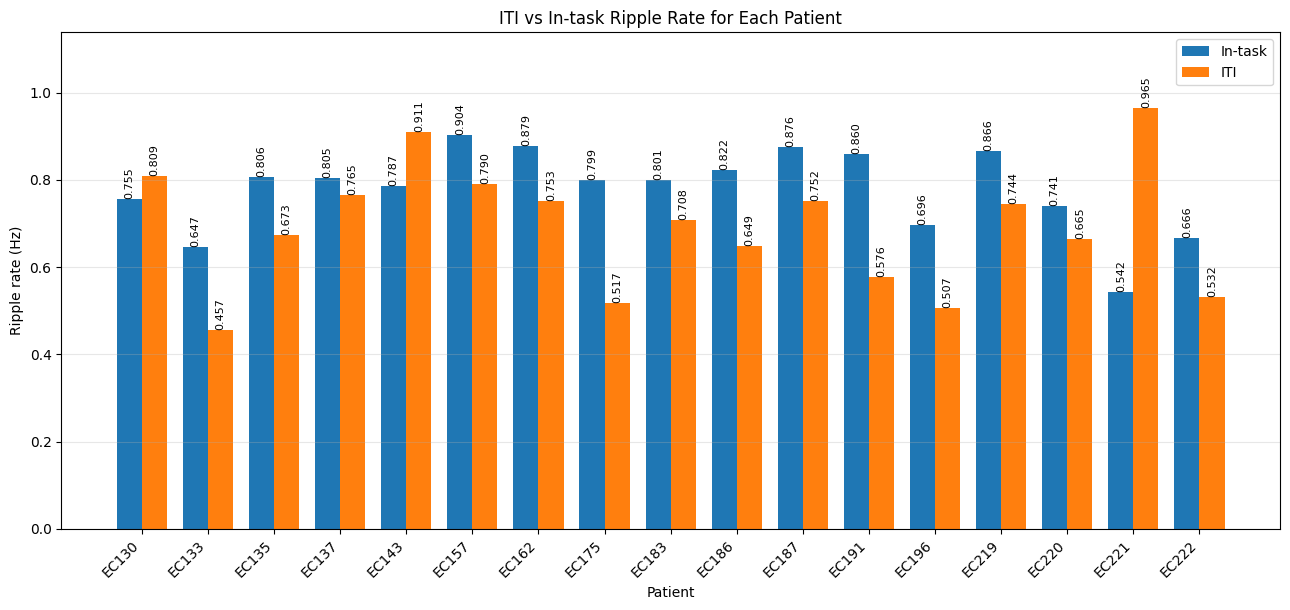

In [2]:
# ============================================================
# FIGURE 1 — PATIENT-WISE RIPPLE RATES
# PLOT ONLY
# ============================================================

x = np.arange(len(patients))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6.2))

bars1 = ax.bar(
    x - width / 2,
    intask_rates,
    width,
    label="In-task"
)

bars2 = ax.bar(
    x + width / 2,
    iti_rates,
    width,
    label="ITI"
)

for bars in (bars1, bars2):
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

ax.set_xlabel("Patient")
ax.set_ylabel("Ripple rate (Hz)")
ax.set_title("ITI vs In-task Ripple Rate for Each Patient")
ax.set_xticks(x)
ax.set_xticklabels(patients, rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

max_value = np.nanmax(
    np.concatenate([intask_rates, iti_rates])
)

ax.set_ylim(
    0,
    max_value * 1.18 if max_value > 0 else 1
)

plt.tight_layout()
plt.show()


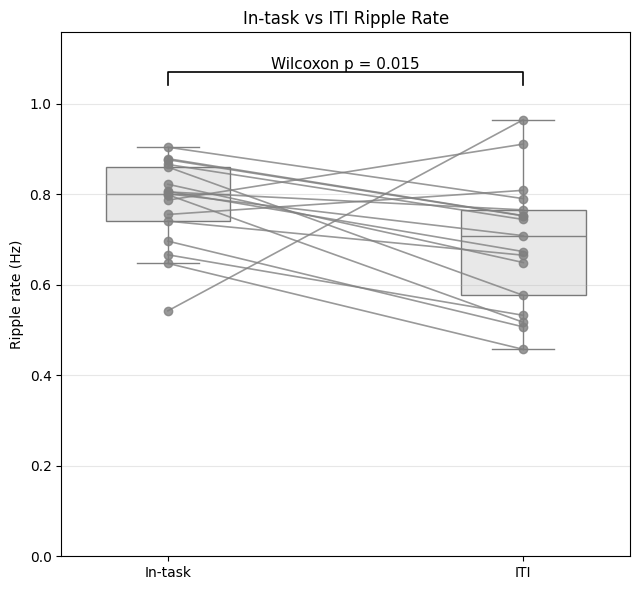

In [3]:
# ============================================================
# FIGURE 2 — PAIRED IN-TASK VS ITI RATES
# PLOT ONLY
#
# Uses the Wilcoxon p-value saved during the first run.
# ============================================================

fig, ax = plt.subplots(figsize=(6.5, 6))

box = ax.boxplot(
    [intask_valid, iti_valid],
    positions=[0, 1],
    widths=0.35,
    patch_artist=True,
    showfliers=False,
    zorder=1
)

for patch in box["boxes"]:
    patch.set_facecolor("lightgray")
    patch.set_alpha(0.5)

for item in ["medians", "whiskers", "caps"]:
    for artist in box[item]:
        artist.set_color("gray")

for i in range(len(intask_valid)):
    ax.plot(
        [0, 1],
        [intask_valid[i], iti_valid[i]],
        marker="o",
        linewidth=1.2,
        alpha=0.8,
        color="gray",
        zorder=3
    )

y_max = max(
    np.max(intask_valid),
    np.max(iti_valid)
)

y = y_max * 1.08
h = y_max * 0.03

ax.plot(
    [0, 0, 1, 1],
    [y, y + h, y + h, y],
    linewidth=1.2,
    color="black"
)

p_text = (
    "p < 0.001"
    if p_value < 0.001
    else f"p = {p_value:.3f}"
)

ax.text(
    0.5,
    y + h,
    f"Wilcoxon {p_text}",
    ha="center",
    va="bottom",
    fontsize=11
)

ax.set_xticks([0, 1])
ax.set_xticklabels(["In-task", "ITI"])
ax.set_ylabel("Ripple rate (Hz)")
ax.set_title("In-task vs ITI Ripple Rate")
ax.set_xlim(-0.3, 1.3)
ax.set_ylim(0, y_max * 1.20)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


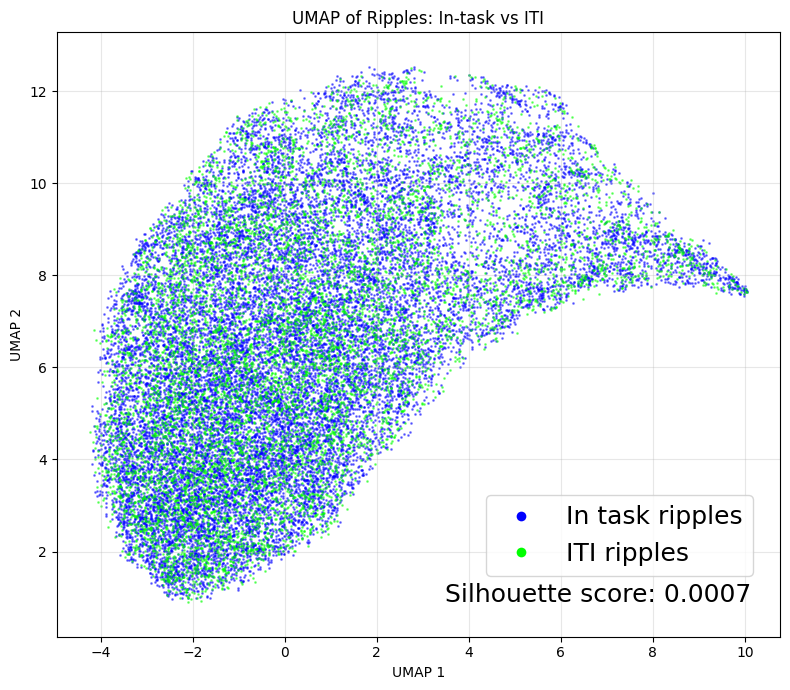

In [4]:
# ============================================================
# FIGURE 3 — UMAP: IN-TASK VS ITI
# PLOT ONLY
#
# Uses saved UMAP coordinates, labels, and silhouette score.
# ============================================================

intask_color = [0, 0, 1]
iti_color = [0, 1, 0]

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    embedding_valid[state_valid == 0, 0],
    embedding_valid[state_valid == 0, 1],
    s=1.0,
    alpha=0.45,
    color=intask_color,
    label="In task ripples"
)

ax.scatter(
    embedding_valid[state_valid == 1, 0],
    embedding_valid[state_valid == 1, 1],
    s=1.0,
    alpha=0.45,
    color=iti_color,
    label="ITI ripples"
)

ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
ax.set_title("UMAP of Ripples: In-task vs ITI")

legend_handles = [
    Line2D(
        [], [],
        linestyle="none",
        marker="o",
        markerfacecolor=intask_color,
        markeredgecolor="none",
        markersize=7,
        label="In task ripples"
    ),
    Line2D(
        [], [],
        linestyle="none",
        marker="o",
        markerfacecolor=iti_color,
        markeredgecolor="none",
        markersize=7,
        label="ITI ripples"
    )
]

legend = ax.legend(
    handles=legend_handles,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.08),
    frameon=True,
    fontsize=18
)

fig.canvas.draw()

legend_bbox = legend.get_window_extent(
    renderer=fig.canvas.get_renderer()
).transformed(ax.transAxes.inverted())

ax.text(
    legend_bbox.x1,
    legend_bbox.y0 - 0.015,
    f"Silhouette score: {silhouette_umap:.4f}",
    transform=ax.transAxes,
    fontsize=18,
    ha="right",
    va="top"
)

ax.grid(True, alpha=0.3)
ax.axis("equal")

plt.tight_layout()
plt.show()


In [5]:
# ============================================================
# PLOT ONLY LOADER — START HERE FOR ALL FUTURE REPRODUCTION
#
# No raw-data loading
# No UMAP fitting
# No silhouette recomputation
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

CACHE_FILE = "SoZ_non_SoZ_last_figure_plot_inputs.npz"

with np.load(CACHE_FILE, allow_pickle=False) as cached:
    embedding = cached["embedding"]
    soz_mask = cached["soz_mask"]
    point_colors = cached["point_colors"]
    soz_non_soz_silhouette_score = float(cached["soz_non_soz_silhouette_score"])

print(f"Loaded: {CACHE_FILE}")
print("Plotting only — no upstream computation is being rerun.")
print("embedding:", embedding.shape)
print("SoZ count:", int(np.sum(soz_mask)))
print("Non-SoZ count:", int(np.sum(~soz_mask)))


Loaded: SoZ_non_SoZ_last_figure_plot_inputs.npz
Plotting only — no upstream computation is being rerun.
embedding: (31847, 2)
SoZ count: 15557
Non-SoZ count: 16290


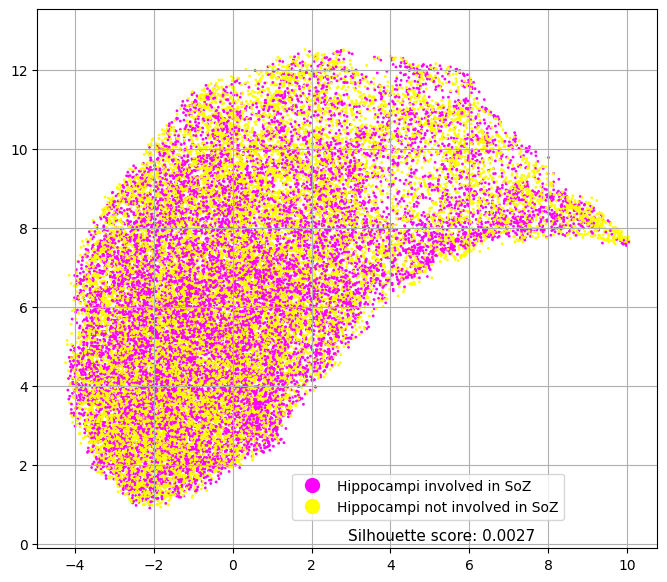

In [6]:
# ============================================================
# LAST FIGURE — PLOT ONLY
# UMAP scatter: hippocampi involved in SoZ vs not involved in SoZ
# ============================================================

from matplotlib.lines import Line2D
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 7))

ax.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=point_colors,
    s=1.0
)

legend_handles = [
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="magenta",
        markeredgecolor="none",
        markersize=11,
        label="Hippocampi involved in SoZ"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="none",
        markerfacecolor="yellow",
        markeredgecolor="none",
        markersize=11,
        label="Hippocampi not involved in SoZ"
    )
]

legend = ax.legend(
    handles=legend_handles,
    loc="lower left",
    bbox_to_anchor=(0.40, 0.04)
)

fig.canvas.draw()

legend_bbox = legend.get_window_extent(
    renderer=fig.canvas.get_renderer()
).transformed(ax.transAxes.inverted())

ax.text(
    legend_bbox.x0 + 0.09,
    legend_bbox.y0 - 0.015,
    f"Silhouette score: {soz_non_soz_silhouette_score:.4f}",
    transform=ax.transAxes,
    fontsize=11,
    ha="left",
    va="top"
)

ax.grid(True)
ax.axis("equal")
plt.show()
